# DeepNetsForEO — Segmentación semántica de imágenes aéreas (ISPRS)
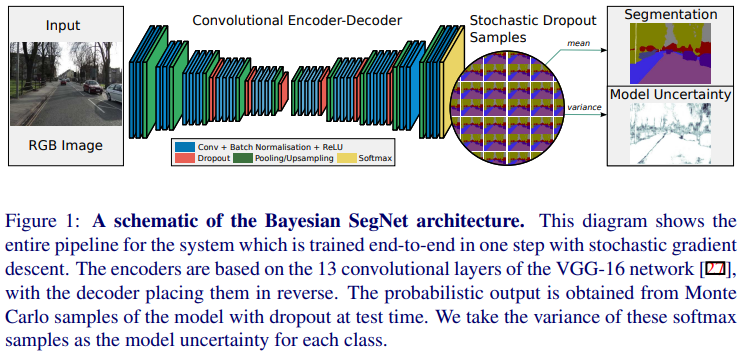

Este notebook implementa un flujo completo de **segmentación semántica por píxel** en imágenes aéreas/urbanas de **muy alta resolución** (Vaihingen/Potsdam, ISPRS 2D Semantic Labeling). Se basa en **PyTorch** e incluye inferencia por **ventana deslizante**, métricas clásicas de teledetección y utilidades de visualización/guardado.

## ¿Qué hace este repositorio?

* **Modelo base:** arquitectura **SegNet** (encoder–decoder con *max-unpooling*), inicializada con **VGG-16** preentrenada (mapeo selectivo de pesos).
* **Datos objetivo:** ciudades **Vaihingen** y **Potsdam** (ISPRS). Usa imágenes RGB/IRRG (según split) y sus **etiquetas en RGB** con paleta estándar ISPRS (6 clases).
* **Preprocesamiento mínimo:** normalización a [0,1]; conversión **RGB → clases** mediante paleta; extracción de **parches** (ventana deslizante) para entrenar/probar.
* **Entrenamiento (opcional):** optimizador **SGD** con *momentum*, *weight decay* y **scheduler multietapa**; posibilidad de *data augmentation* (flips).
* **Inferencia robusta:** barrido por parches con **solape controlado** (stride), acumulación de logits y **ensamblaje** del mapa de clases completo del tile.
* **Métricas incluidas:** **Accuracy global**, **F1** por clase, **Kappa**; compatible tanto con GT “normal” como con GT **eroded** (si está disponible).
* **Salida de resultados:** guardado de predicciones **a color (paleta ISPRS)** como PNG y, opcionalmente, exportación a **GeoTIFF** preservando georreferencia.

## Conjuntos y paleta de clases (ISPRS)

* **Clases (6):** superficies impermeables, edificios, vegetación baja, árboles, autos, *clutter*.
* **Paleta ISPRS (RGB):** blanco, azul, cian, verde, amarillo, rojo (más negro para “undefined” si aplica).
* **Vaihingen:** `top/top_mosaic_09cm_areaXX.tif` (imágenes) y `gts_for_participants/...areaXX.tif` (GT).
* **Potsdam:** `2_Ortho_RGB/top_potsdam_*_RGB.tif` (imágenes) y `5_Labels_for_participants/..._label.tif` (GT).

## Diseño del modelo (SegNet)

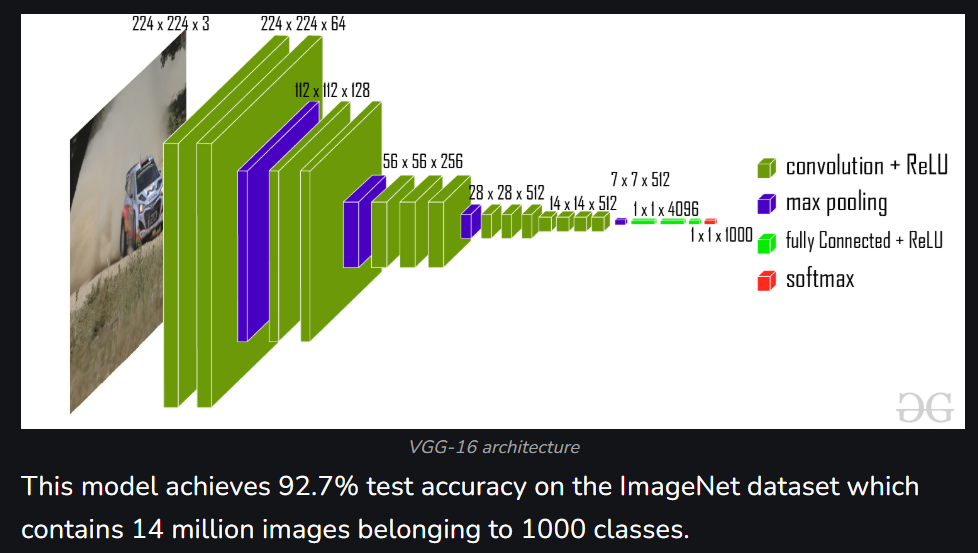

* **Encoder**: bloques conv + BN + ReLU + *max-pooling* (con índices).
* **Decoder**: *max-unpooling* con los índices del encoder + conv + BN.
* **Salida**: mapa **(N_CLASSES, H, W)** con **log-softmax(dim=1)** para usar pérdida de entropía cruzada 2D.

## Flujo típico (del repo original)

1. **Configurar parámetros** (ventana, stride, rutas, canales, clases).
2. **Cargar datos** (imágenes + GT), convertir GT RGB→clases.
3. **Instanciar SegNet** y (opcional) **cargar pesos VGG-16**/checkpoints.
4. **Entrenar** (opcional) con SGD y *scheduler*.
5. **Inferir** con ventana deslizante (stride ajustable).
6. **Evaluar** (Accuracy, F1, Kappa) y **guardar** resultados (PNG/GeoTIFF).

## Notas de uso en Colab (esta adaptación)

* **Rutas autodetectadas** para Vaihingen/Potsdam y ajuste automático de `FOLDER/DATA_FOLDER/LABEL_FOLDER`.
* **Compatibilidad** con `log_softmax(..., dim=1)` en PyTorch recientes.
* **Split robusto** por *glob* (sin listas fijas), y **carga de pesos** desde `weights/segnet_final_reference.pth`.
* **Inferencia con padding** de parches para evitar errores de forma en bordes.



> ### Paso 1.0 — Limpieza total del entorno en `/content`
>
> Esta celda **desmonta Google Drive** (sin borrar nada en la nube) y **elimina carpetas temporales** dentro de `/content` para empezar desde cero. Úsala cuando cambies de dataset, rutas o tras varios intentos fallidos, para evitar que queden archivos/residuos de ejecuciones anteriores.
>
> **Qué hace:**
>
> * Desmonta `/content/drive` de forma segura.
> * Borra directorios y notebooks previos en `/content` (solo dentro de esa ruta, por seguridad).
> * Muestra un resumen de lo **eliminado** y lo **omitido**.



In [3]:
# === RESET LIMPIO DEL ENTORNO EN /content ===
import os, shutil, sys, subprocess

# 1) Desmontar Google Drive si está montado (no borra tus archivos en la nube)
try:
    from google.colab import drive
    drive.flush_and_unmount()
except Exception:
    pass
# Intento extra: desmontar por sistema
subprocess.run("fusermount -u /content/drive 2>/dev/null || true", shell=True)
subprocess.run("umount /content/drive 2>/dev/null || true", shell=True)

# 2) Carpetas/archivos a limpiar (agrega/quita lo que quieras)
TARGETS = [
    "/content/DeepNetsForEO",
    "/content/data",
    "/content/sample_data",
    "/content/drive",  # solo el punto de montaje
    "/content/config_deepnets_eo.json",
    "/content/SegNet_PyTorch_v2_colab.ipynb",
    "/content/SegNet_PyTorch_v2_launcher.ipynb",
    "/content/DeepNetsForEO/SegNet_PyTorch_v2_colab.ipynb",
    "/content/DeepNetsForEO/SegNet_PyTorch_v2_launcher.ipynb",
]

removed, skipped = [], []

def safe_rm(path):
    # Solo permitimos borrar bajo /content por seguridad
    if not os.path.abspath(path).startswith("/content"):
        skipped.append((path, "fuera de /content"))
        return
    if not os.path.exists(path):
        skipped.append((path, "no existe"))
        return
    try:
        if os.path.isdir(path) and not os.path.islink(path):
            shutil.rmtree(path)
        else:
            os.remove(path)
        removed.append(path)
    except Exception as e:
        skipped.append((path, f"error: {e}"))

for p in TARGETS:
    safe_rm(p)

print("=== LIMPIEZA COMPLETA ===")
print("Eliminado:")
for p in removed: print(" -", p)
print("\nOmitido:")
for p, why in skipped: print(f" - {p} ({why})")


Drive not mounted, so nothing to flush and unmount.
=== LIMPIEZA COMPLETA ===
Eliminado:

Omitido:
 - /content/DeepNetsForEO (no existe)
 - /content/data (no existe)
 - /content/sample_data (no existe)
 - /content/drive (no existe)
 - /content/config_deepnets_eo.json (no existe)
 - /content/SegNet_PyTorch_v2_colab.ipynb (no existe)
 - /content/SegNet_PyTorch_v2_launcher.ipynb (no existe)
 - /content/DeepNetsForEO/SegNet_PyTorch_v2_colab.ipynb (no existe)
 - /content/DeepNetsForEO/SegNet_PyTorch_v2_launcher.ipynb (no existe)


> ### Paso 1.1 — Montar Google Drive y fijar rutas base
>
> Esta celda monta tu **Google Drive** en `/content/drive` y define las rutas principales del proyecto:
>
> * `PROJECT_ROOT`: carpeta del repositorio en `/content`.
> * `DATA_ROOT`: ubicación donde se **extraerán** los datos ISPRS.
> * `WEIGHTS_DIR`: directorio para **pesos preentrenados**.
>   Además crea estas carpetas si no existen y lista posibles ubicaciones en Drive donde podrías tener el **RAR** de ISPRS. Ajusta las rutas si guardaste tus archivos en otra carpeta.


In [4]:
# === PASO 1.1: Montar Google Drive y definir rutas base ===
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import os, sys, json

# Cambia estos si quieres otra estructura
PROJECT_ROOT = Path('/content/DeepNetsForEO')
DATA_ROOT    = Path('/content/data/ISPRS')  # aquí dejaremos los datos extraídos
WEIGHTS_DIR  = PROJECT_ROOT / 'weights'     # aquí pondremos los pesos preentrenados (más adelante)

# Donde CREES que está tu RAR (ajusta si lo guardaste en otra carpeta de Drive)
# Intentaremos localizarlo automáticamente:
CANDIDATE_DIRS = [
    Path('/content/drive/MyDrive'),
    Path('/content/drive/MyDrive/Datasets'),
    Path('/content/drive/MyDrive/data'),
    Path('/content/drive/MyDrive/ISPRS')
]

for p in [PROJECT_ROOT, DATA_ROOT, WEIGHTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT   :", DATA_ROOT)
print("WEIGHTS_DIR :", WEIGHTS_DIR)
print("CANDIDATE_DIRS:", CANDIDATE_DIRS)

Mounted at /content/drive
PROJECT_ROOT: /content/DeepNetsForEO
DATA_ROOT   : /content/data/ISPRS
WEIGHTS_DIR : /content/DeepNetsForEO/weights
CANDIDATE_DIRS: [PosixPath('/content/drive/MyDrive'), PosixPath('/content/drive/MyDrive/Datasets'), PosixPath('/content/drive/MyDrive/data'), PosixPath('/content/drive/MyDrive/ISPRS')]


> ### Paso 1.2 — Localizar `ISPRS_dataset.rar` en tu Drive
>
>
> Esta celda **busca automáticamente** el archivo `ISPRS_dataset.rar` dentro de las carpetas candidatas de tu Google Drive (definidas en la celda anterior).
>
> * Si lo encuentra, muestra la **ruta exacta**.
> * Si **no** lo encuentra, lanza un mensaje con instrucciones para **mover el archivo** a una carpeta de *MyDrive* o **actualizar** la lista `CANDIDATE_DIRS`.
>   Úsala antes de la extracción para asegurarte de que el dataset está disponible.


In [5]:
# === PASO 1.2: Buscar el archivo ISPRS_dataset.rar en Drive ===
from pathlib import Path

rar_path = None
for base in CANDIDATE_DIRS:
    if not base.exists():
        continue
    matches = list(base.rglob('ISPRS_dataset.rar'))
    if matches:
        rar_path = matches[0]
        break

if rar_path is None:
    # Si no se encontró, imprime sugerencias
    raise FileNotFoundError(
        "No encontré 'ISPRS_dataset.rar' en las ubicaciones conocidas.\n"
        "Mueve el archivo a tu MyDrive o actualiza CANDIDATE_DIRS en la celda anterior."
    )
else:
    print("Encontrado:", rar_path)


Encontrado: /content/drive/MyDrive/ISPRS_dataset.rar


> ### Paso 1.3 — Instalar `unrar` para extraer el dataset
>
> Esta celda instala la herramienta **`unrar`** en el entorno de Colab. Es necesaria para **descomprimir** el archivo `ISPRS_dataset.rar` desde Google Drive hacia `/content`.
> Ejecútala **una sola vez** por sesión antes de la celda de **extracción**.


In [6]:
# === PASO 1.3: Instalar 'unrar' para extraer RAR ===
!apt-get -yqq update
!apt-get -yqq install unrar

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


> ### Paso 1.4 — Extraer el RAR en `DATA_ROOT`
>
> Esta celda **descomprime** `ISPRS_dataset.rar` dentro de la carpeta `DATA_ROOT` (p. ej. `/content/data/ISPRS`).
>
> * Usa `unrar x -o+` para **sobrescribir** archivos existentes sin preguntar (útil si repetiste el proceso).
> * Si quieres una extracción completamente limpia, puedes **borrar el destino** antes (línea comentada).
> * Al final, muestra un **listado** del contenido extraído para verificar que la estructura quedó correcta.


In [7]:
# === PASO 1.4: Extraer el RAR al DATA_ROOT ===
import subprocess, shlex

# Limpiar destino si quieres una extracción limpia (opcional):
# !rm -rf /content/data/ISPRS/*

cmd = f'unrar x -o+ {shlex.quote(str(rar_path))} {shlex.quote(str(DATA_ROOT))}/'
print("Ejecutando:", cmd)
!$cmd

# Mostrar una vista rápida del contenido extraído
!echo "Listado de primer nivel en DATA_ROOT:" && ls -lah {str(DATA_ROOT)}


Ejecutando: unrar x -o+ /content/drive/MyDrive/ISPRS_dataset.rar /content/data/ISPRS/

UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/drive/MyDrive/ISPRS_dataset.rar

Creating    /content/data/ISPRS/ISPRS_dataset                         OK
Creating    /content/data/ISPRS/ISPRS_dataset/Vaihingen               OK
Creating    /content/data/ISPRS/ISPRS_dataset/Vaihingen/dsm           OK
Extracting  /content/data/ISPRS/ISPRS_dataset/Vaihingen/dsm/dsm_09cm_matching_area1.tif       0%  1%  OK 
Extracting  /content/data/ISPRS/ISPRS_dataset/Vaihingen/dsm/dsm_09cm_matching_area10.tif       2%  OK 
Extracting  /content/data/ISPRS/ISPRS_dataset/Vaihingen/dsm/dsm_09cm_matching_area11.tif       3%  OK 
Extracting  /content/data/ISPRS/ISPRS_dataset/Vaihingen/dsm/dsm_09cm_matching_area12.tif       4%  5%  OK 
Extracting  /content/data/ISPRS/ISPRS_dataset/Vaihingen/dsm/dsm_09cm_matching_area13.tif      

> ### Paso 1.5 — Clonar el repositorio (copia limpia)
>
> Esta celda prepara una **copia fresca** del repositorio en `/content/DeepNetsForEO`:
>
> * Cambia al directorio `/content`.
> * **Elimina** cualquier carpeta previa `DeepNetsForEO` para evitar conflictos.
> * Hace un **clone superficial** (`--depth=1`) desde GitHub para descargar solo la última revisión (más rápido).
> * Entra al repo y lista su **contenido** para verificar que todo está en su lugar.


In [8]:
# === PASO 1.5: Clonar el repo ===
%cd /content
!rm -rf DeepNetsForEO
!git clone --depth=1 https://github.com/nshaud/DeepNetsForEO.git
%cd DeepNetsForEO
!ls -lah


/content
Cloning into 'DeepNetsForEO'...
remote: Enumerating objects: 778, done.
remote: Counting objects: 100% (778/778), done.
remote: Compressing objects: 100% (572/572), done.
remote: Total 778 (delta 191), reused 763 (delta 190), pack-reused 0 (from 0)
Receiving objects: 100% (778/778), 8.72 MiB | 30.48 MiB/s, done.
Resolving deltas: 100% (191/191), done.
/content/DeepNetsForEO
total 840K
drwxr-xr-x 6 root root 4.0K Oct  1 04:49 .
drwxr-xr-x 1 root root 4.0K Oct  1 04:49 ..
drwxr-xr-x 8 root root 4.0K Oct  1 04:49 .git
-rw-r--r-- 1 root root   19 Oct  1 04:49 .gitignore
-rw-r--r-- 1 root root    0 Oct  1 04:49 .gitmodules
drwxr-xr-x 5 root root 4.0K Oct  1 04:49 legacy
-rw-r--r-- 1 root root 3.1K Oct  1 04:49 LICENSE.md
drwxr-xr-x 2 root root 4.0K Oct  1 04:49 OSM
-rw-r--r-- 1 root root 5.1K Oct  1 04:49 README.md
-rw-r--r-- 1 root root 2.2K Oct  1 04:49 References.bib
-rw-r--r-- 1 root root  891 Oct  1 04:49 requirements.txt
drwxr-xr-x 3 root root 4.0K Oct  1 04:49 s2reader
-rw-r

> ### Paso 1.6 — Instalar dependencias del repositorio
>
> Esta celda instala primero las **dependencias declaradas** por el repo (`requirements.txt`) y, si algo falla (común en repos antiguos), añade un **paquete suplementario** de librerías compatibles con Colab actual (imagen, raster, E/S de TIFF, progreso, etc.).
> Ejecuta esta celda **antes** de correr cualquier notebook del repo para evitar errores de importación.


In [9]:
# === PASO 1.6: Instalar dependencias del repo ===
# Intento 1: instalar exactamente lo que pide el repo
!pip install -q -r requirements.txt || echo "Fallo parcial con requirements.txt (normal en repos antiguos)."

# Intento 2 (suplemento): librerías útiles y compatibles con Colab actual
!pip install -q opencv-python scikit-image rasterio tifffile albumentations==1.4.7 matplotlib tqdm


  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
Fallo parcial con requirements.txt (normal en repos antiguos).
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.7/155.7 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 108.7 MB/s eta 0:00:00


> ### Paso 1.7 — Comprobar PyTorch y la GPU
>
> Esta celda muestra la **versión de PyTorch**, verifica si **CUDA está disponible** y, en ese caso, imprime el **nombre de la GPU** detectada por Colab. También reporta la **versión de Python**. Úsala para confirmar que podrás ejecutar el modelo **en GPU** (mucho más rápido que en CPU) antes de seguir con el resto del flujo.


In [10]:
# === PASO 1.7: Verificar que PyTorch ve la GPU ===
import torch, platform
print("PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Python:", platform.python_version())


PyTorch: 2.8.0+cu126
CUDA disponible: True
GPU: Tesla T4
Python: 3.12.11


> ### Paso 1.8 — Revisar la estructura del dataset
>
> Esta celda recorre el directorio de datos (`DATA_ROOT`) y muestra un **resumen del árbol** (cantidad de archivos/carpetas y las primeras rutas encontradas). Sirve para **verificar** que la extracción del RAR dejó la **estructura correcta**.
> Además intenta **autodetectar** directorios típicos de `images/` y `labels/` para que puedas asignarlos rápidamente si tu proyecto los usa. Ajusta las variables si tu organización de carpetas es diferente.


In [11]:
# === PASO 1.8: Echar un vistazo a la estructura de los datos ===
from pathlib import Path

def tree(path: Path, max_items=30):
    items = list(path.rglob('*'))
    print(f"Total items under {path}: {len(items)}")
    for i, p in enumerate(items[:max_items], 1):
        print(f"{i:>3}.", p.relative_to(path))
    if len(items) > max_items:
        print("...")

# Muestra primer nivel y algunas rutas típicas
tree(DATA_ROOT, max_items=50)

# Si sabes dónde están imágenes y máscaras, configura estas variables ya:
# (AJUSTA estos nombres a tu estructura real)
IMAGES_DIR = next((p for p in DATA_ROOT.rglob('images') if p.is_dir()), None)
LABELS_DIR = next((p for p in DATA_ROOT.rglob('labels') if p.is_dir()), None)

print("IMAGES_DIR:", IMAGES_DIR)
print("LABELS_DIR:", LABELS_DIR)


Total items under /content/data/ISPRS: 88
  1. ISPRS_dataset
  2. ISPRS_dataset/Vaihingen
  3. ISPRS_dataset/Vaihingen/gts_for_participants
  4. ISPRS_dataset/Vaihingen/top
  5. ISPRS_dataset/Vaihingen/dsm
  6. ISPRS_dataset/Vaihingen/gts_for_participants/top_mosaic_09cm_area1.tif
  7. ISPRS_dataset/Vaihingen/gts_for_participants/top_mosaic_09cm_area30.tif
  8. ISPRS_dataset/Vaihingen/gts_for_participants/top_mosaic_09cm_area3.tif
  9. ISPRS_dataset/Vaihingen/gts_for_participants/top_mosaic_09cm_area5(1).tif
 10. ISPRS_dataset/Vaihingen/gts_for_participants/top_mosaic_09cm_area37.tif
 11. ISPRS_dataset/Vaihingen/gts_for_participants/top_mosaic_09cm_area26.tif
 12. ISPRS_dataset/Vaihingen/gts_for_participants/top_mosaic_09cm_area32.tif
 13. ISPRS_dataset/Vaihingen/gts_for_participants/top_mosaic_09cm_area34.tif
 14. ISPRS_dataset/Vaihingen/gts_for_participants/top_mosaic_09cm_area21.tif
 15. ISPRS_dataset/Vaihingen/gts_for_participants/top_mosaic_09cm_area13.tif
 16. ISPRS_dataset/Vaihi

> ### Paso 1.9 — Guardar configuración reutilizable (JSON)
>
> Esta celda **centraliza** las rutas clave del proyecto en un archivo JSON (`/content/config_deepnets_eo.json`): `PROJECT_ROOT`, `DATA_ROOT`, `WEIGHTS_DIR`, y (si existen) `IMAGES_DIR`/`LABELS_DIR`.
> Te permite **reutilizar** esta configuración en celdas/notebooks posteriores sin volver a definir rutas, mejora la **reproducibilidad** y facilita mover el flujo entre sesiones o equipos (solo cargando el JSON).


In [12]:
# === PASO 1.9: Centralizar configuración en un JSON para reutilizar ===
cfg = {
    "PROJECT_ROOT": str(PROJECT_ROOT),
    "DATA_ROOT":    str(DATA_ROOT),
    "WEIGHTS_DIR":  str(WEIGHTS_DIR),
    "IMAGES_DIR":   str(IMAGES_DIR) if IMAGES_DIR else None,
    "LABELS_DIR":   str(LABELS_DIR) if LABELS_DIR else None,
}
with open('/content/config_deepnets_eo.json', 'w') as f:
    json.dump(cfg, f, indent=2)
print("Config guardada en /content/config_deepnets_eo.json")
!cat /content/config_deepnets_eo.json


Config guardada en /content/config_deepnets_eo.json
{
  "PROJECT_ROOT": "/content/DeepNetsForEO",
  "DATA_ROOT": "/content/data/ISPRS",
  "WEIGHTS_DIR": "/content/DeepNetsForEO/weights",
  "IMAGES_DIR": null,
  "LABELS_DIR": null
}

> ### Paso 2.1 — Cargar configuración y fijar rutas de trabajo
>
> Esta celda **lee el JSON de configuración** creado en el Paso 1 (`/content/config_deepnets_eo.json`) y restaura `PROJECT_ROOT`, `DATA_ROOT` y `WEIGHTS_DIR`.
> Si `IMAGES_DIR`/`LABELS_DIR` no quedaron definidos, intenta **autodetectarlos** dentro de `DATA_ROOT` (buscando carpetas típicas o la que contenga más imágenes).
> Al final imprime las rutas detectadas y valida que exista una carpeta de **imágenes** antes de continuar.


In [13]:
# === PASO 2.1: Cargar la configuración del Paso 1 y fijar rutas ===
import json, os
from pathlib import Path

# Cargar lo que guardamos en el Paso 1
with open('/content/config_deepnets_eo.json') as f:
    cfg = json.load(f)

PROJECT_ROOT = Path(cfg["PROJECT_ROOT"])
DATA_ROOT    = Path(cfg["DATA_ROOT"])
WEIGHTS_DIR  = Path(cfg["WEIGHTS_DIR"])
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

# Trata de adivinar IMAGES_DIR y LABELS_DIR si quedaron en None
IMAGES_DIR = Path(cfg["IMAGES_DIR"]) if cfg.get("IMAGES_DIR") else None
LABELS_DIR = Path(cfg["LABELS_DIR"]) if cfg.get("LABELS_DIR") else None

def guess_subdir(root: Path, names=('images','img','imgs','IRRG','rgb','tiles')):
    for n in names:
        cand = list(root.rglob(n))
        for p in cand:
            if p.is_dir(): return p
    # fallback: el primer directorio con muchas imágenes
    exts = {'.tif','.tiff','.png','.jpg','.jpeg'}
    best = None; best_count = 0
    for p in root.rglob('*'):
        if p.is_dir():
            c = sum(1 for f in p.iterdir() if f.suffix.lower() in exts)
            if c > best_count:
                best, best_count = p, c
    return best

def guess_labels(root: Path, names=('labels','gt','groundtruth','gt_labels','masks')):
    for n in names:
        cand = list(root.rglob(n))
        for p in cand:
            if p.is_dir(): return p
    return None

if IMAGES_DIR is None: IMAGES_DIR = guess_subdir(DATA_ROOT)
if LABELS_DIR is None: LABELS_DIR = guess_labels(DATA_ROOT)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT   :", DATA_ROOT)
print("IMAGES_DIR  :", IMAGES_DIR)
print("LABELS_DIR  :", LABELS_DIR)
assert IMAGES_DIR and IMAGES_DIR.exists(), "No se detectó carpeta de imágenes"


PROJECT_ROOT: /content/DeepNetsForEO
DATA_ROOT   : /content/data/ISPRS
IMAGES_DIR  : /content/data/ISPRS/ISPRS_dataset/Vaihingen/top
LABELS_DIR  : None


> ### Paso 2.2 — Muestreo y **MANIFEST** para el notebook
>
> Esta celda recorre las carpetas de **imágenes** y **labels**, empareja archivos por nombre (ignorando extensión) y construye un **MANIFEST** (`manifest_isprs.csv`) con las rutas completas.
>
> * Muestra un **preview** de las primeras filas para validar correspondencias.
> * Indica cuántas imágenes tienen **label** disponible.
> * El MANIFEST servirá para que el notebook consuma rutas de forma **estable y reproducible** en los siguientes pasos (inferencia, métricas, exportación).


In [14]:
# === PASO 2.2: Listar algunos ejemplos y crear un MANIFEST para el notebook ===
from pathlib import Path
import pandas as pd

exts = {'.tif','.tiff','.png','.jpg','.jpeg'}

# Emparejar por nombre (ignorando extensión) si hay labels
def stem_map(folder: Path):
    m = {}
    for f in folder.rglob('*'):
        if f.is_file() and f.suffix.lower() in exts:
            m[f.stem] = f
    return m

img_map = stem_map(IMAGES_DIR)
lbl_map = stem_map(LABELS_DIR) if LABELS_DIR and LABELS_DIR.exists() else {}

rows = []
for stem, img in img_map.items():
    lbl = lbl_map.get(stem) if lbl_map else None
    rows.append({"stem": stem, "image_path": str(img), "label_path": str(lbl) if lbl else ""})

df = pd.DataFrame(rows).sort_values("stem")
print("Total imágenes:", len(df), " — con label:", (df["label_path"]!="").sum())
display(df.head(10))

MANIFEST_CSV = PROJECT_ROOT / "manifest_isprs.csv"
df.to_csv(MANIFEST_CSV, index=False)
print("Manifest guardado en:", MANIFEST_CSV)


Total imágenes: 33  — con label: 0


,stem,image_path,label_path
1,top_mosaic_09cm_area1,/content/data/ISPRS/ISPRS_dataset/Vaihingen/to...,
9,top_mosaic_09cm_area10,/content/data/ISPRS/ISPRS_dataset/Vaihingen/to...,
31,top_mosaic_09cm_area11,/content/data/ISPRS/ISPRS_dataset/Vaihingen/to...,
8,top_mosaic_09cm_area12,/content/data/ISPRS/ISPRS_dataset/Vaihingen/to...,
17,top_mosaic_09cm_area13,/content/data/ISPRS/ISPRS_dataset/Vaihingen/to...,
24,top_mosaic_09cm_area14,/content/data/ISPRS/ISPRS_dataset/Vaihingen/to...,
20,top_mosaic_09cm_area15,/content/data/ISPRS/ISPRS_dataset/Vaihingen/to...,
5,top_mosaic_09cm_area16,/content/data/ISPRS/ISPRS_dataset/Vaihingen/to...,
22,top_mosaic_09cm_area17,/content/data/ISPRS/ISPRS_dataset/Vaihingen/to...,
14,top_mosaic_09cm_area2,/content/data/ISPRS/ISPRS_dataset/Vaihingen/to...,


Manifest guardado en: /content/DeepNetsForEO/manifest_isprs.csv


> ### Paso 2.3 — Descargar pesos preentrenados (backup con `gdown`)
>
> Esta celda obtiene el checkpoint **`segnet_final_reference.pth`** desde Google Drive (ID público) y lo guarda en `WEIGHTS_DIR`.
>
> * Si el archivo **ya existe**, no vuelve a descargar.
> * Estos pesos sirven para **hacer inferencia inmediata** (o acelerar convergencia si entrenas).
> * Ejecuta esta celda **una vez por sesión** o cuando borres `WEIGHTS_DIR`.


In [15]:
# === PASO 2.3: Descargar pesos preentrenados con gdown ===
!pip -q install gdown

# ID del backup de pesos enlazado desde el README (Google Drive)
GDRIVE_ID = "1cwXe8ANkhFqe2i_UNxpZu15y2HZ0N9KN"  # segnet_final_reference.pth (backup)
OUT_PATH = WEIGHTS_DIR / "segnet_final_reference.pth"

import os
if not OUT_PATH.exists():
    !gdown --id {GDRIVE_ID} -O {str(OUT_PATH)}
else:
    print("Pesos ya existen:", OUT_PATH)

!ls -lh {str(WEIGHTS_DIR)}


/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1cwXe8ANkhFqe2i_UNxpZu15y2HZ0N9KN
From (redirected): https://drive.google.com/uc?id=1cwXe8ANkhFqe2i_UNxpZu15y2HZ0N9KN&confirm=t&uuid=2f75c62f-2219-4e4a-b45c-0684890817f8
To: /content/DeepNetsForEO/weights/segnet_final_reference.pth
100% 118M/118M [00:01<00:00, 63.3MB/s]
total 113M
-rw-r--r-- 1 root root 113M Jan 26  2018 segnet_final_reference.pth


> ### Paso 2.4 — **Autoparchear** el notebook del repo y crear un *launcher*
>
> Esta celda automatiza la adaptación del notebook original a tu entorno de Colab:
>
> * **Detecta** automáticamente si el dataset es **Vaihingen** o **Potsdam** y compone las rutas `DATA_FOLDER`, `LABEL_FOLDER`, etc.
> * **Parchea** el notebook (`SegNet_PyTorch_v2.ipynb`) para: fijar rutas, ajustar `log_softmax(dim=1)`, desactivar el split fijo de ejemplo y **cargar pesos preentrenados**.
> * **Genera** un notebook derivado (*launcher*) que **omite** la demo de visualización y el entrenamiento, y añade un **split robusto** + **test rápido**.


> * **Ejecuta** el launcher al final para validar que todo quedó bien conectado.


In [16]:
# === AUTO PATCH + LAUNCH (2.4 todo-en-uno) ===
!pip -q install nbformat nbclient

import nbformat, uuid, re, os, glob, json
from nbclient import NotebookClient
from pathlib import Path

# --- Paths base ---
REPO_NB = Path("/content/DeepNetsForEO/SegNet_PyTorch_v2.ipynb")
COLAB_NB = Path("/content/DeepNetsForEO/SegNet_PyTorch_v2_colab.ipynb")
LAUNCH_NB = Path("/content/DeepNetsForEO/SegNet_PyTorch_v2_launcher.ipynb")
PRETRAINED = "/content/DeepNetsForEO/weights/segnet_final_reference.pth"

assert REPO_NB.exists(), f"No se encontró {REPO_NB}. ¿Clonaste el repo en /content?"

# --- 1) DETECTAR dataset y rutas reales (Vaihingen/Potsdam) ---
SEARCH_ROOTS = [
    "/content/data", "/content",
    "/content/drive/MyDrive", "/content/drive/MyDrive/ISPRS", "/content/drive"
]

def find_all(pats):
    hits=[]
    for root in SEARCH_ROOTS:
        for pat in pats:
            hits += glob.glob(os.path.join(root, pat), recursive=True)
    return sorted(set(hits))

# Vaihingen
vai_img = find_all(["**/Vaihingen/**/top/top_mosaic_09cm_area*.tif"])
vai_gt  = find_all(["**/Vaihingen/**/gts_for_participants/top_mosaic_09cm_area*.tif"])
vai_er  = find_all(["**/Vaihingen/**/gts_eroded_for_participants/top_mosaic_09cm_area*_noBoundary.tif"])

# Potsdam RGB
pot_img = find_all(["**/Potsdam/**/2_Ortho_RGB/top_potsdam_*_RGB.tif"])
pot_gt  = find_all(["**/Potsdam/**/5_Labels_for_participants/top_potsdam_*_label.tif"])
pot_er  = find_all(["**/Potsdam/**/5_Labels_for_participants_no_Boundary/top_potsdam_*_label_noBoundary.tif"])

if vai_img and vai_gt:
    DATASET = "Vaihingen"
    IMG_DIR = os.path.dirname(vai_img[0])
    GT_DIR  = os.path.dirname(vai_gt[0])
    ER_DIR  = os.path.dirname(vai_er[0]) if vai_er else GT_DIR
    MAIN_FOLDER = os.path.dirname(os.path.dirname(IMG_DIR)) + "/"
    DATA_FOLDER = f"{IMG_DIR}/top_mosaic_09cm_area{{}}.tif"
    LABEL_FOLDER = f"{GT_DIR}/top_mosaic_09cm_area{{}}.tif"
    ERODED_FOLDER = f"{ER_DIR}/top_mosaic_09cm_area{{}}_noBoundary.tif" if vai_er else LABEL_FOLDER
elif pot_img and pot_gt:
    DATASET = "Potsdam"
    IMG_DIR = os.path.dirname(pot_img[0])
    GT_DIR  = os.path.dirname(pot_gt[0])
    ER_DIR  = os.path.dirname(pot_er[0]) if pot_er else GT_DIR
    MAIN_FOLDER = os.path.dirname(os.path.dirname(IMG_DIR)) + "/"
    DATA_FOLDER = f"{IMG_DIR}/top_potsdam_{{}}_RGB.tif"
    LABEL_FOLDER = f"{GT_DIR}/top_potsdam_{{}}_label.tif"
    ERODED_FOLDER = f"{ER_DIR}/top_potsdam_{{}}_label_noBoundary.tif" if pot_er else LABEL_FOLDER
else:
    print("No se detectaron rutas estándar. Muestra de .tif encontrados cerca:")
    show = []
    for root in SEARCH_ROOTS:
        show += glob.glob(os.path.join(root, "**/*.tif"), recursive=True)
    for p in sorted(set(show))[:50]:
        print("-", p)
    raise RuntimeError("No pude detectar Vaihingen ni Potsdam. Verifica la estructura de tus datos.")

print("=== DETECCIÓN ===")
print(json.dumps({
    "DATASET": DATASET,
    "MAIN_FOLDER": MAIN_FOLDER,
    "DATA_FOLDER": DATA_FOLDER,
    "LABEL_FOLDER": LABEL_FOLDER,
    "ERODED_FOLDER": ERODED_FOLDER
}, indent=2))

# --- 2) PARCHEAR notebook del repo -> colab ---
nb = nbformat.read(REPO_NB.open(), as_version=4)

def ensure_ids(n):
    for c in n.cells:
        if "id" not in c:
            c["id"] = uuid.uuid4().hex

def sub(text, mapping):
    for pat, repl in mapping:
        # Faltaba pasar 'text' como 3er argumento a re.sub
        text = re.sub(pat, repl, text, flags=re.MULTILINE)
    return text

changes = {"parameters": False, "visualization": False, "log_softmax": False, "insert_weights": False, "comment_fixed_split": False}

insert_after = None
for i, cell in enumerate(nb.cells):
    if cell.cell_type != "code":
        continue
    src = cell.source

    # Parameters
    if "WINDOW_SIZE" in src and "FOLDER" in src and "LABELS" in src:
        new_src = sub(src, [
            (r"^FOLDER\s*=.*$",               f'FOLDER = "{MAIN_FOLDER}"'),
            (r"^CACHE\s*=.*$",                'CACHE = False'),
            (r"^DATASET\s*=.*$",              f"DATASET = '{DATASET}'"),
        ])
        if DATASET == "Vaihingen":
            new_src = re.sub(
                r"elif DATASET == 'Vaihingen':[\s\S]*?$",
                "elif DATASET == 'Vaihingen':\n"
                f"    MAIN_FOLDER = '{MAIN_FOLDER}'\n"
                f"    DATA_FOLDER = '{DATA_FOLDER}'\n"
                f"    LABEL_FOLDER = '{LABEL_FOLDER}'\n"
                f"    ERODED_FOLDER = '{ERODED_FOLDER}'\n",
                new_src, flags=re.MULTILINE)
        else:
            new_src = re.sub(
                r"if DATASET == 'Potsdam':[\s\S]*?elif DATASET == 'Vaihingen':",
                "if DATASET == 'Potsdam':\n"
                f"    MAIN_FOLDER = '{MAIN_FOLDER}'\n"
                f"    DATA_FOLDER = '{DATA_FOLDER}'\n"
                f"    LABEL_FOLDER = '{LABEL_FOLDER}'\n"
                f"    ERODED_FOLDER = '{ERODED_FOLDER}'\n"
                "\nelif DATASET == 'Vaihingen':",
                new_src, flags=re.MULTILINE)
        if new_src != src:
            cell.source = new_src
            changes["parameters"] = True

    # Visualización: la saltaremos en el launcher, así que no es obligatorio tocarla.

    # log_softmax(..., dim=1)
    if "F.log_softmax(self.conv1_1_D(x))" in src:
        cell.source = src.replace("F.log_softmax(self.conv1_1_D(x))",
                                  "F.log_softmax(self.conv1_1_D(x), dim=1)")
        changes["log_softmax"] = True

    # Insertar weights después de net = SegNet()
    if re.search(r'^\s*net\s*=\s*SegNet\s*\(\s*\)\s*$', src, flags=re.MULTILINE):
        insert_after = i

    # Comentar split fijo de ejemplo
    if "# Exemple of a train/test split on Vaihingen" in nb.cells[i-1].source if i>0 and nb.cells[i-1].cell_type=="markdown" else False:
        lines=[]
        for line in src.splitlines():
            if line.strip().startswith("train_ids = [") or line.strip().startswith("test_ids = ["):
                lines.append("# "+line)
            else:
                lines.append(line)
        cell.source = "\n".join(lines)
        changes["comment_fixed_split"] = True

# Insertar celda de pesos preentrenados
if insert_after is not None:
    nb.cells.insert(insert_after+1, nbformat.v4.new_code_cell(f"""# === Cargar pesos preentrenados (Colab) ===
ckpt_path = "{PRETRAINED}"
import torch
try:
    state = torch.load(ckpt_path, map_location="cpu")
    missing = net.load_state_dict(state, strict=False)
    print("Pesos cargados desde", ckpt_path)
    print("Claves faltantes/diferentes:", missing)
except Exception as e:
    print("No se pudieron cargar los pesos preentrenados:", e)
"""))
    changes["insert_weights"] = True

ensure_ids(nb)
nbformat.write(nb, COLAB_NB.open("w"))
print("Notebook parcheado ->", COLAB_NB)
print(json.dumps(changes, indent=2))

# --- 3) CREAR LAUNCHER (sin visualización/entrenamiento/segnet_final) ---
src = nbformat.read(COLAB_NB.open(), as_version=4)
new_cells=[]
saw_pretrained=False

def skip_visual_demo(code:str)->bool:
    pats=[r"io\.imread\(.+ISPRS/", r"GT \(RGB labels\)", r"Ejemplo seleccionado automáticamente:", r"plt\.imshow\("]
    return any(re.search(p, code) for p in pats)

def skip_training(code:str)->bool:
    return bool(re.search(r'\btrain\s*\(\s*net\s*,\s*optimizer', code))

def skip_checkpoint_loads(code:str)->bool:
    return ("torch.load('./segnet_final" in code) or ("segnet256_epoch" in code)

def skip_notebook_test_call(code:str)->bool:
    return bool(re.search(r'\btest\s*\(\s*net\s*,\s*test_ids.*all\s*=\s*True', code))

def skip_original_split(code:str)->bool:
    return "# Load the datasets" in code or "Tiles for training" in code

for c in src.cells:
    if c.cell_type!="code":
        new_cells.append(c); continue
    code=c.source
    if skip_visual_demo(code) or skip_training(code) or skip_checkpoint_loads(code) or skip_notebook_test_call(code) or skip_original_split(code):
        continue
    new_cells.append(c)
    if f'ckpt_path = "{PRETRAINED}"' in code:
        saw_pretrained=True

if not saw_pretrained:
    new_cells.append(nbformat.v4.new_code_cell(f"""# (Respaldo) Carga de pesos preentrenados
ckpt_path = "{PRETRAINED}"
import torch
try:
    state = torch.load(ckpt_path, map_location="cpu")
    net.load_state_dict(state, strict=False)
    print("Pesos cargados desde", ckpt_path)
except Exception as e:
    print("No se pudieron cargar los pesos preentrenados:", e)
"""))

# Split robusto
new_cells.append(nbformat.v4.new_code_cell(r"""# === Split robusto (funciona aunque haya pocos tiles) ===
from glob import glob
import os, random, re

def _list_ids(label_glob, dataset):
    files = sorted(glob(label_glob))
    ids=[]
    if dataset=='Vaihingen':
        for f in files:
            b=os.path.basename(f); m=re.search(r'area(\d+)\.', b)
            if m: ids.append(m.group(1))
    else:
        for f in files:
            b=os.path.basename(f); m=re.search(r'top_potsdam_(\d+)_(\d+)_label', b)
            if m: ids.append(f"{m.group(1)}_{m.group(2)}")
    return files, ids

label_glob = LABEL_FOLDER.replace("{}", "*")
label_files, all_ids = _list_ids(label_glob, DATASET)
print("LABEL pattern:", label_glob)
print("labels encontrados:", len(label_files))
print("IDs:", all_ids)

n=len(all_ids)
if n==0: raise RuntimeError("No hay tiles en LABEL_FOLDER. Revisa arriba las rutas.")
elif n==1: train_ids, test_ids = [], [all_ids[0]]
elif n==2: train_ids, test_ids = [all_ids[0]], [all_ids[1]]
else:
    k=max(1,(2*n)//3); k=min(k,n-1)
    random.seed(42)
    train_ids = random.sample(all_ids, k)
    test_ids  = [i for i in all_ids if i not in train_ids]

print("Train IDs:", train_ids)
print("Test  IDs:", test_ids)

if len(train_ids)>0:
    train_set = ISPRS_dataset(train_ids, cache=CACHE)
    train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE)
else:
    train_loader=None
print("train_loader:", type(train_loader).__name__ if train_loader else None)
"""))

# Test rápido
new_cells.append(nbformat.v4.new_code_cell("""# === Test rápido (sin visualización ni entrenamiento) ===
try:
    acc = test(net, test_ids, all=False, stride=128)
    print("\\n>>> ACCURACY (test rápido):", acc)
except Exception as e:
    print("El test no pudo ejecutarse. Verifica DATA_FOLDER/LABEL_FOLDER. Error:", e)
"""))

derived = nbformat.v4.new_notebook()
derived.cells = new_cells
derived.metadata = src.metadata
ensure_ids(derived)
nbformat.write(derived, LAUNCH_NB.open("w"))
print("Launcher creado ->", LAUNCH_NB)

# --- 4) EJECUTAR LAUNCHER ---
client = NotebookClient(derived, timeout=None, kernel_name="python3")
client.execute()
print("\\n=== EJECUCIÓN COMPLETA DEL LAUNCHER ===")


=== DETECCIÓN ===
{
  "DATASET": "Vaihingen",
  "MAIN_FOLDER": "/content/data/ISPRS/ISPRS_dataset/",
  "DATA_FOLDER": "/content/data/ISPRS/ISPRS_dataset/Vaihingen/top/top_mosaic_09cm_area{}.tif",
  "LABEL_FOLDER": "/content/data/ISPRS/ISPRS_dataset/Vaihingen/gts_for_participants/top_mosaic_09cm_area{}.tif",
  "ERODED_FOLDER": "/content/data/ISPRS/ISPRS_dataset/Vaihingen/gts_for_participants/top_mosaic_09cm_area{}.tif"
}
Notebook parcheado -> /content/DeepNetsForEO/SegNet_PyTorch_v2_colab.ipynb
{
  "parameters": true,
  "visualization": false,
  "log_softmax": true,
  "insert_weights": true,
  "comment_fixed_split": false
}
Launcher creado -> /content/DeepNetsForEO/SegNet_PyTorch_v2_launcher.ipynb
\n=== EJECUCIÓN COMPLETA DEL LAUNCHER ===


> ### Paso 2.5 — Crear el modelo `SegNet` y cargar pesos
>
> Esta celda define la arquitectura **SegNet** (encoder–decoder con *max-unpooling*), fija los **parámetros esenciales** (`IN_CHANNELS`, `LABELS`, `N_CLASSES`), instancia el modelo (`net`) en **GPU** si está disponible y **carga el checkpoint** `segnet_final_reference.pth` desde `WEIGHTS_DIR`.
>
> * Ajusta `IN_CHANNELS`/`LABELS` si cambias de dataset o número de clases.
> * Si el checkpoint no existe, el modelo queda **inicializado aleatoriamente** (sirve para test rápido del flujo o como base para entrenamiento).
> * Deja `net` listo para usar en **inferencias** (2.5A) o **entrenamiento** posterior.


In [17]:
# === 2.5-boot: crear 'net' y cargar pesos preentrenados ===
import os, torch, torch.nn as nn, torch.nn.functional as F

# --- Parámetros mínimos (ajusta si los cambiaste)
IN_CHANNELS = 3
LABELS = ["roads", "buildings", "low veg.", "trees", "cars", "clutter"]
N_CLASSES = len(LABELS)

# --- Definición del modelo (SegNet, versión del repo con log_softmax(dim=1))
class SegNet(nn.Module):
    @staticmethod
    def weight_init(m):
        if isinstance(m, nn.Linear):
            torch.nn.init.kaiming_normal_(m.weight.data)

    def __init__(self, in_channels=IN_CHANNELS, out_channels=N_CLASSES):
        super().__init__()
        self.pool = nn.MaxPool2d(2, return_indices=True)
        self.unpool = nn.MaxUnpool2d(2)

        self.conv1_1 = nn.Conv2d(in_channels, 64, 3, padding=1); self.conv1_1_bn = nn.BatchNorm2d(64)
        self.conv1_2 = nn.Conv2d(64, 64, 3, padding=1);          self.conv1_2_bn = nn.BatchNorm2d(64)

        self.conv2_1 = nn.Conv2d(64, 128, 3, padding=1);  self.conv2_1_bn = nn.BatchNorm2d(128)
        self.conv2_2 = nn.Conv2d(128, 128, 3, padding=1); self.conv2_2_bn = nn.BatchNorm2d(128)

        self.conv3_1 = nn.Conv2d(128, 256, 3, padding=1); self.conv3_1_bn = nn.BatchNorm2d(256)
        self.conv3_2 = nn.Conv2d(256, 256, 3, padding=1); self.conv3_2_bn = nn.BatchNorm2d(256)
        self.conv3_3 = nn.Conv2d(256, 256, 3, padding=1); self.conv3_3_bn = nn.BatchNorm2d(256)

        self.conv4_1 = nn.Conv2d(256, 512, 3, padding=1); self.conv4_1_bn = nn.BatchNorm2d(512)
        self.conv4_2 = nn.Conv2d(512, 512, 3, padding=1); self.conv4_2_bn = nn.BatchNorm2d(512)
        self.conv4_3 = nn.Conv2d(512, 512, 3, padding=1); self.conv4_3_bn = nn.BatchNorm2d(512)

        self.conv5_1 = nn.Conv2d(512, 512, 3, padding=1); self.conv5_1_bn = nn.BatchNorm2d(512)
        self.conv5_2 = nn.Conv2d(512, 512, 3, padding=1); self.conv5_2_bn = nn.BatchNorm2d(512)
        self.conv5_3 = nn.Conv2d(512, 512, 3, padding=1); self.conv5_3_bn = nn.BatchNorm2d(512)

        self.conv5_3_D = nn.Conv2d(512, 512, 3, padding=1); self.conv5_3_D_bn = nn.BatchNorm2d(512)
        self.conv5_2_D = nn.Conv2d(512, 512, 3, padding=1); self.conv5_2_D_bn = nn.BatchNorm2d(512)
        self.conv5_1_D = nn.Conv2d(512, 512, 3, padding=1); self.conv5_1_D_bn = nn.BatchNorm2d(512)

        self.conv4_3_D = nn.Conv2d(512, 512, 3, padding=1); self.conv4_3_D_bn = nn.BatchNorm2d(512)
        self.conv4_2_D = nn.Conv2d(512, 512, 3, padding=1); self.conv4_2_D_bn = nn.BatchNorm2d(512)
        self.conv4_1_D = nn.Conv2d(512, 256, 3, padding=1); self.conv4_1_D_bn = nn.BatchNorm2d(256)

        self.conv3_3_D = nn.Conv2d(256, 256, 3, padding=1); self.conv3_3_D_bn = nn.BatchNorm2d(256)
        self.conv3_2_D = nn.Conv2d(256, 256, 3, padding=1); self.conv3_2_D_bn = nn.BatchNorm2d(256)
        self.conv3_1_D = nn.Conv2d(256, 128, 3, padding=1); self.conv3_1_D_bn = nn.BatchNorm2d(128)

        self.conv2_2_D = nn.Conv2d(128, 128, 3, padding=1); self.conv2_2_D_bn = nn.BatchNorm2d(128)
        self.conv2_1_D = nn.Conv2d(128, 64, 3, padding=1);  self.conv2_1_D_bn = nn.BatchNorm2d(64)

        self.conv1_2_D = nn.Conv2d(64, 64, 3, padding=1); self.conv1_2_D_bn = nn.BatchNorm2d(64)
        self.conv1_1_D = nn.Conv2d(64, N_CLASSES, 3, padding=1)

        self.apply(self.weight_init)

    def forward(self, x):
        x = self.conv1_1_bn(F.relu(self.conv1_1(x))); x = self.conv1_2_bn(F.relu(self.conv1_2(x))); x, m1 = self.pool(x)
        x = self.conv2_1_bn(F.relu(self.conv2_1(x))); x = self.conv2_2_bn(F.relu(self.conv2_2(x))); x, m2 = self.pool(x)
        x = self.conv3_1_bn(F.relu(self.conv3_1(x))); x = self.conv3_2_bn(F.relu(self.conv3_2(x))); x = self.conv3_3_bn(F.relu(self.conv3_3(x))); x, m3 = self.pool(x)
        x = self.conv4_1_bn(F.relu(self.conv4_1(x))); x = self.conv4_2_bn(F.relu(self.conv4_2(x))); x = self.conv4_3_bn(F.relu(self.conv4_3(x))); x, m4 = self.pool(x)
        x = self.conv5_1_bn(F.relu(self.conv5_1(x))); x = self.conv5_2_bn(F.relu(self.conv5_2(x))); x = self.conv5_3_bn(F.relu(self.conv5_3(x))); x, m5 = self.pool(x)

        x = self.unpool(x, m5); x = self.conv5_3_D_bn(F.relu(self.conv5_3_D(x))); x = self.conv5_2_D_bn(F.relu(self.conv5_2_D(x))); x = self.conv5_1_D_bn(F.relu(self.conv5_1_D(x)))
        x = self.unpool(x, m4); x = self.conv4_3_D_bn(F.relu(self.conv4_3_D(x))); x = self.conv4_2_D_bn(F.relu(self.conv4_2_D(x))); x = self.conv4_1_D_bn(F.relu(self.conv4_1_D(x)))
        x = self.unpool(x, m3); x = self.conv3_3_D_bn(F.relu(self.conv3_3_D(x))); x = self.conv3_2_D_bn(F.relu(self.conv3_2_D(x))); x = self.conv3_1_D_bn(F.relu(self.conv3_1_D(x)))
        x = self.unpool(x, m2); x = self.conv2_2_D_bn(F.relu(self.conv2_2_D(x))); x = self.conv2_1_D_bn(F.relu(self.conv2_1_D(x)))
        x = self.unpool(x, m1); x = self.conv1_2_D_bn(F.relu(self.conv1_2_D(x)))
        return F.log_softmax(self.conv1_1_D(x), dim=1)

# Instanciar + cargar pesos
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = SegNet().to(device)

ckpt_path = "/content/DeepNetsForEO/weights/segnet_final_reference.pth"
if os.path.exists(ckpt_path):
    try:
        state = torch.load(ckpt_path, map_location=device)
        net.load_state_dict(state, strict=False)
        print("Pesos cargados desde", ckpt_path)
    except Exception as e:
        print("No se pudieron cargar los pesos:", e)
else:
    print("Advertencia: no existe", ckpt_path, "→ el modelo funcionará sin pesos preentrenados.")


Pesos cargados desde /content/DeepNetsForEO/weights/segnet_final_reference.pth


> ### Paso 2.5A — Inferencia robusta con **padding** de parches
>
> Esta celda ejecuta la **inferencia por ventanas deslizantes** sobre los `test_ids` y **almohadilla (pad)** cada parche al tamaño `WINDOW_SIZE` para evitar errores de forma en bordes o en tiles más pequeños.
> **Qué hace:**
>
> * Detecta automáticamente los **IDs** de test desde `LABEL_FOLDER`.
> * Recorre cada tile con **stride** configurable (`STRIDE`) y acumula los **logits** para ensamblar el mapa completo.
> * Aplica `argmax` y **guarda** las predicciones coloreadas (paleta ISPRS) en `/content/DeepNetsForEO/out`.
>   **Requisitos:** haber ejecutado antes **2.5-boot** (modelo `net` cargado) y tener definidas `DATA_FOLDER`, `LABEL_FOLDER`.
>   **Parámetros útiles:**
> * `STRIDE` (64 por defecto, súbelo a 128/256 si falta memoria).
> * `WINDOW_SIZE` (coincidir con el del modelo; por defecto 256×256).
> * Carpeta de salida: `/content/DeepNetsForEO/out` (puedes cambiarla si vas a correr varios tests).


In [18]:
# === 2.5A-rescue (fix shapes): inferencia con padding de parches ===
import os, re, math, numpy as np
from glob import glob
from skimage import io
import torch
import torch.nn.functional as F
from tqdm import tqdm

assert 'DATA_FOLDER' in globals() and 'LABEL_FOLDER' in globals(), "No están definidas DATA_FOLDER/LABEL_FOLDER."
assert 'net' in globals(), "El modelo 'net' no existe (ejecuta antes 2.5-boot)."

# Paleta ISPRS
palette = {0:(255,255,255), 1:(0,0,255), 2:(0,255,255), 3:(0,255,0), 4:(255,255,0), 5:(255,0,0), 6:(0,0,0)}
invert_palette = {v:k for k,v in palette.items()}

def convert_to_color(arr_2d, palette=palette):
    arr_3d = np.zeros((arr_2d.shape[0], arr_2d.shape[1], 3), dtype=np.uint8)
    for c, rgb in palette.items():
        arr_3d[arr_2d==c] = rgb
    return arr_3d

def convert_from_color(arr_3d, palette=invert_palette):
    arr_2d = np.zeros((arr_3d.shape[0], arr_3d.shape[1]), dtype=np.uint8)
    for c, i in palette.items():
        m = np.all(arr_3d == np.array(c).reshape(1,1,3), axis=2)
        arr_2d[m] = i
    return arr_2d

# Helpers ventana
def sliding_window(img, step, window_size):
    H, W = img.shape[0], img.shape[1]
    w, h = window_size
    # Si la imagen es más pequeña que la ventana: una sola posición (0,0)
    if H <= w or W <= h:
        yield 0, 0, w, h
        return
    xs = list(range(0, H - w + 1, step)); ys = list(range(0, W - h + 1, step))
    if xs[-1] != H - w: xs.append(H - w)
    if ys[-1] != W - h: ys.append(W - h)
    for x in xs:
        for y in ys:
            yield x, y, w, h

def pad_to_window(patch, w, h):
    """Devuelve patch (H,W,C) rellenado a (w,h,C) con ceros si hace falta."""
    H, W, C = patch.shape
    if H == w and W == h:
        return patch
    out = np.zeros((w, h, C), dtype=patch.dtype)
    out[:H, :W, :] = patch
    return out

# Detectar IDs desde labels
label_glob = LABEL_FOLDER.replace("{}", "*")
label_files = sorted(glob(label_glob))
assert label_files, f"No se hallaron labels con patrón: {label_glob}"

if 'Vaihingen' in (globals().get('DATASET') or ''):
    def extract_id(p):
        b = os.path.basename(p); m = re.search(r'area(\d+)\.', b)
        return m.group(1) if m else None
else:
    def extract_id(p):
        b = os.path.basename(p); m = re.search(r'top_potsdam_(\d+)_(\d+)_label', b)
        return f"{m.group(1)}_{m.group(2)}" if m else None

all_ids = [extract_id(p) for p in label_files if extract_id(p) is not None]
assert all_ids, "No pude extraer IDs de tus labels."

# Split robusto
if len(all_ids) == 1:
    train_ids, test_ids = [], [all_ids[0]]
elif len(all_ids) == 2:
    train_ids, test_ids = [all_ids[0]], [all_ids[1]]
else:
    import random
    random.seed(42)
    k = max(1, (2*len(all_ids))//3); k = min(k, len(all_ids)-1)
    train_ids = random.sample(all_ids, k)
    test_ids  = [i for i in all_ids if i not in train_ids]

print("Test IDs:", test_ids)

# Parámetros
WINDOW_SIZE = tuple(globals().get('WINDOW_SIZE', (256,256)))
STRIDE = 64            # sube a 128/256 si falta memoria
BATCH_SIZE = int(globals().get('BATCH_SIZE', 10))
N_CLASSES = int(globals().get('N_CLASSES', 6))

net.eval()
device = next(net.parameters()).device

def load_img(id_):
    img = io.imread(DATA_FOLDER.format(id_)).astype('float32') / 255.0
    # Asegura (H,W,C)
    if img.ndim == 2: img = np.stack([img]*3, axis=2)
    return img

def load_gt_rgb(id_):
    return io.imread(LABEL_FOLDER.format(id_)).astype('uint8')

all_preds, all_gts = [], []

for id_ in tqdm(test_ids, desc="Inferencia tiles"):
    img = load_img(id_)          # (H,W,C)
    gt_rgb = load_gt_rgb(id_)    # (H,W,3)
    gt = convert_from_color(gt_rgb)

    H, W, C = img.shape
    w, h = WINDOW_SIZE
    pred_accum = np.zeros((H, W, N_CLASSES), dtype=np.float32)

    coords = list(sliding_window(img, step=STRIDE, window_size=WINDOW_SIZE))
    for i in range(0, len(coords), BATCH_SIZE):
        batch = coords[i:i+BATCH_SIZE]
        patches = []
        for (x,y,w_,h_) in batch:
            p = img[x:x+w_, y:y+h_, :]
            p = pad_to_window(p, w, h)         # <-- padding consistente
            p = np.transpose(p, (2,0,1))       # (C,w,h)
            patches.append(p)
        patches = np.stack(patches, axis=0).astype('float32')

        with torch.no_grad():
            t = torch.from_numpy(patches).to(device)
            out = net(t)                        # (B, N_CLASSES, w, h), log-probs
            out = out.detach().cpu().numpy().transpose(0,2,3,1)  # (B,w,h,N_CLASSES)

        for o, (x,y,_,_) in zip(out, batch):
            pred_accum[x:x+w, y:y+h, :] += o

    pred = np.argmax(pred_accum, axis=-1)
    all_preds.append(pred)
    all_gts.append(gt)

# Guardar
outdir = "/content/DeepNetsForEO/out"
os.makedirs(outdir, exist_ok=True)
for pred, id_ in zip(all_preds, test_ids):
    img_col = convert_to_color(pred)
    io.imsave(os.path.join(outdir, f"prediction_area{id_}.png"), img_col)
    print("guardado:", os.path.join(outdir, f"prediction_area{id_}.png"))

print("\nInferencia completa. Archivos en:", outdir)



Test IDs: ['21', '23', '26', '3', '30', '5']


Inferencia tiles: 100%|██████████| 6/6 [02:14<00:00, 22.42s/it]


guardado: /content/DeepNetsForEO/out/prediction_area21.png
guardado: /content/DeepNetsForEO/out/prediction_area23.png
guardado: /content/DeepNetsForEO/out/prediction_area26.png
guardado: /content/DeepNetsForEO/out/prediction_area3.png
guardado: /content/DeepNetsForEO/out/prediction_area30.png
guardado: /content/DeepNetsForEO/out/prediction_area5.png

Inferencia completa. Archivos en: /content/DeepNetsForEO/out


> ### Paso 2.5B — Visualización rápida (RGB, GT, Pred y Overlay)
>
>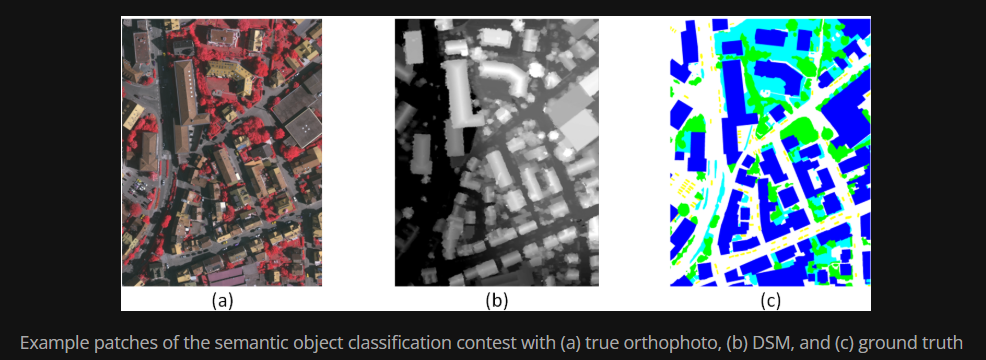
>
> Esta celda muestra, para un `tile_id` de test, la **imagen RGB**, la **verdad terreno (GT)**, la **predicción** coloreada y una **superposición** semitransparente (*overlay*) entre RGB y Pred.
> **Uso:** asegúrate de haber corrido la inferencia (2.5A) para que exista `prediction_area{tile_id}.png`. Puedes cambiar `tile_id` para revisar otros tiles.
> **Nota:** si ves descuadres, verifica que `DATA_FOLDER`, `LABEL_FOLDER` y la carpeta de **out** correspondan al **mismo conjunto** y tamaño de imagen.


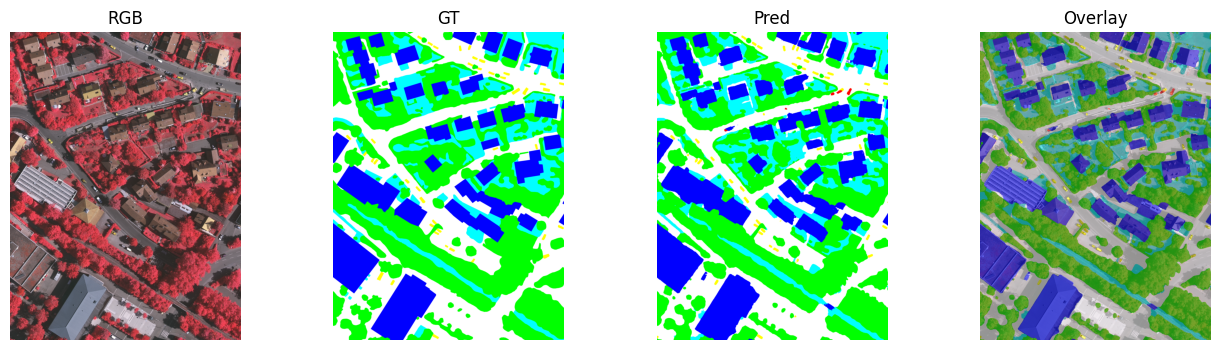

In [19]:
# === 2.5C: Visualización rápida (RGB, GT, Pred, Overlay) ===
import os, re, numpy as np
import matplotlib.pyplot as plt
from skimage import io

# Paleta y helpers (por si no están en memoria)
palette = {0:(255,255,255),1:(0,0,255),2:(0,255,255),3:(0,255,0),4:(255,255,0),5:(255,0,0),6:(0,0,0)}
invert_palette = {v:k for k,v in palette.items()}
def convert_to_color(arr_2d, palette=palette):
    arr_3d = np.zeros((arr_2d.shape[0], arr_2d.shape[1], 3), dtype=np.uint8)
    for c, rgb in palette.items(): arr_3d[arr_2d==c] = rgb
    return arr_3d
def convert_from_color(arr_3d, palette=invert_palette):
    arr_2d = np.zeros((arr_3d.shape[0], arr_3d.shape[1]), dtype=np.uint8)
    for c,i in palette.items():
        m = np.all(arr_3d == np.array(c).reshape(1,1,3), axis=2)
        arr_2d[m] = i
    return arr_2d

# elige un ID de test (por ejemplo el primero)
tile_id = test_ids[0]

rgb = io.imread(DATA_FOLDER.format(tile_id))
gt_rgb = io.imread(LABEL_FOLDER.format(tile_id))
gt = convert_from_color(gt_rgb)
pred = io.imread(f"/content/DeepNetsForEO/out/prediction_area{tile_id}.png")
pred_num = convert_from_color(pred)

alpha = 0.5
overlay = (alpha*rgb + (1-alpha)*pred).astype(np.uint8)

fig, ax = plt.subplots(1,4, figsize=(16,4))
ax[0].imshow(rgb);        ax[0].set_title("RGB");  ax[0].axis("off")
ax[1].imshow(gt_rgb);     ax[1].set_title("GT");   ax[1].axis("off")
ax[2].imshow(pred);       ax[2].set_title("Pred"); ax[2].axis("off")
ax[3].imshow(overlay);    ax[3].set_title("Overlay"); ax[3].axis("off")
plt.show()


> ### Paso 2.6 — Calcular métricas sobre `test_ids`
>
> Esta celda evalúa las predicciones contra la verdad terreno y reporta:
>
> * **Matriz de confusión** global (todas las clases).
> * **Overall Accuracy (OA)**.
> * **F1 por clase** e **IoU por clase**.
> * **mIoU** (promedio de IoU) y **Kappa**.
>   Toma las máscaras de predicción guardadas en `/content/DeepNetsForEO/out/` y las compara con los **labels RGB** convertidos a índices. Úsala después de la inferencia (2.5A) para obtener los números finales de desempeño.


In [20]:
# === 2.6: Métricas sobre test_ids ===
import numpy as np
from sklearn.metrics import confusion_matrix

labels = ["roads","buildings","low veg.","trees","cars","clutter"]
n_classes = len(labels)

def fast_confusion(pred, gt, n_classes):
    return confusion_matrix(gt.ravel(), pred.ravel(), labels=list(range(n_classes)))

def scores_from_cm(cm):
    # Overall accuracy
    total = cm.sum()
    oa = np.trace(cm) / total if total>0 else 0.0
    # F1 por clase
    f1 = []
    iou = []
    for i in range(cm.shape[0]):
        tp = cm[i,i]
        fp = cm[:,i].sum() - tp
        fn = cm[i,:].sum() - tp
        denom_f1 = (2*tp + fp + fn)
        denom_iou = (tp + fp + fn)
        f1.append( 0.0 if denom_f1==0 else (2*tp) / denom_f1 )
        iou.append(0.0 if denom_iou==0 else tp / denom_iou)
    miou = float(np.mean(iou))
    # Kappa
    pe = (cm.sum(axis=0)*cm.sum(axis=1)).sum() / (total*total)
    kappa = (oa - pe) / (1 - pe) if (1-pe)!=0 else 0.0
    return oa, f1, iou, miou, kappa

cm_total = np.zeros((n_classes, n_classes), dtype=np.int64)
for tid in test_ids:
    gt_rgb = io.imread(LABEL_FOLDER.format(tid))
    gt = convert_from_color(gt_rgb)
    pred_rgb = io.imread(f"/content/DeepNetsForEO/out/prediction_area{tid}.png")
    pred = convert_from_color(pred_rgb)
    cm_total += fast_confusion(pred, gt, n_classes)

oa, f1, iou, miou, kappa = scores_from_cm(cm_total)

print("Confusion matrix:\n", cm_total)
print("\nOverall Accuracy:", round(oa*100, 3), "%")
print("F1 por clase:")
for name, s in zip(labels, f1): print(f"  {name:10s}: {round(s,4)}")
print("IoU por clase:")
for name, s in zip(labels, iou): print(f"  {name:10s}: {round(s,4)}")
print("mIoU:", round(miou,4))
print("Kappa:", round(kappa,4))


Confusion matrix:
 [[8357450  212818  153988  187676   34507   13735]
 [ 331402 8342350   66991   35663     700    4959]
 [ 205368  104473 4250876  492230     500    6227]
 [ 143108   32411  345949 6706308    1520    3864]
 [  52456    3957    1157    2958  291556    2057]
 [  20293  275399     502    8321       0  150375]]

Overall Accuracy: 91.1 %
F1 por clase:
  roads     : 0.925
  buildings : 0.9398
  low veg.  : 0.8606
  trees     : 0.9145
  cars      : 0.8538
  clutter   : 0.4728
IoU por clase:
  roads     : 0.8605
  buildings : 0.8864
  low veg.  : 0.7553
  trees     : 0.8425
  cars      : 0.745
  clutter   : 0.3096
mIoU: 0.7332
Kappa: 0.8812


> ### Paso 2.7 — Empaquetar predicciones para descargar
>
> Esta celda comprime la carpeta de **salidas** (`/content/DeepNetsForEO/out`) en un único archivo **ZIP** para facilitar la descarga y el intercambio. Al finalizar, te mostrará la ruta del archivo generado (`/content/predicciones_isprs_vaihingen.zip`). Ejecuta este paso después de tener las predicciones listas.


In [21]:
# === 2.7: Empaquetar predicciones para descarga ===
!zip -r -q /content/predicciones_isprs_vaihingen.zip /content/DeepNetsForEO/out
print("Listo: /content/predicciones_isprs_vaihingen.zip")

Listo: /content/predicciones_isprs_vaihingen.zip


> ### Paso 2.8 — Exportar predicciones como **GeoTIFF** con georreferencia
>
> Esta celda convierte cada máscara de predicción (PNG) en un **GeoTIFF de 1 banda (uint8)** usando la **georreferencia** (CRS, `transform`, tamaño) del tile RGB original.
>
> * Salida en: `/content/DeepNetsForEO/out_geotiff/` con el nombre `prediction_area{ID}.tif`.
> * Los valores de píxel son **índices de clase** (0–5).
> * La **paleta de colores** no se guarda en el GeoTIFF (solo clases). Visualiza en tu SIG asignando simbología por valor.
> * Úsalo cuando necesites integrar resultados en **QGIS/ArcGIS** o flujos GIS posteriores, preservando la referencia espacial.


In [22]:
# === 2.8: Exportar GeoTIFFs con georreferencia (clasificación por píxel) ===
!pip -q install rasterio

import rasterio
from rasterio.transform import Affine

save_dir = "/content/DeepNetsForEO/out_geotiff"
os.makedirs(save_dir, exist_ok=True)

for tid in test_ids:
    src_path = DATA_FOLDER.format(tid)  # usamos metadatos del RGB
    pred_rgb = io.imread(f"/content/DeepNetsForEO/out/prediction_area{tid}.png")
    pred = convert_from_color(pred_rgb).astype(np.uint8)  # clases 0..5

    with rasterio.open(src_path) as src:
        meta = src.meta.copy()
        # Guardamos como 1 banda, tipo uint8
        meta.update(count=1, dtype="uint8")

        dst_path = os.path.join(save_dir, f"prediction_area{tid}.tif")
        with rasterio.open(dst_path, 'w', **meta) as dst:
            dst.write(pred, 1)
    print("GeoTIFF:", dst_path)

print("Listo. Carpeta:", save_dir)


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:366: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  dataset = writer(


GeoTIFF: /content/DeepNetsForEO/out_geotiff/prediction_area21.tif


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:366: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  dataset = writer(


GeoTIFF: /content/DeepNetsForEO/out_geotiff/prediction_area23.tif


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:366: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  dataset = writer(


...

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:366: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  dataset = writer(


GeoTIFF: /content/DeepNetsForEO/out_geotiff/prediction_area3.tif


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:366: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  dataset = writer(


GeoTIFF: /content/DeepNetsForEO/out_geotiff/prediction_area30.tif
GeoTIFF: /content/DeepNetsForEO/out_geotiff/prediction_area5.tif
Listo. Carpeta: /content/DeepNetsForEO/out_geotiff


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:366: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  dataset = writer(


# Reseña y reconocimientos

Este trabajo adapta y automatiza el flujo de **segmentación semántica de imágenes aéreas** del repositorio **DeepNetsForEO** para ejecutarlo en Google Colab sobre el **ISPRS 2D Semantic Labeling** (Vaihingen/Potsdam). El pipeline reproduce la arquitectura **SegNet** con pesos iniciales de **VGG-16**, añade utilidades de inferencia por ventanas, métricas (OA, F1, IoU, mIoU, Kappa) y exportación de resultados (PNG y GeoTIFF con georreferencia).

**Créditos principales**

* **Repositorio original:** *DeepNetsForEO* — autor: **Nicolas Audebert** (nshaud) y colaboradores.
* **Referencia académica:** *Beyond RGB: Very High Resolution Urban Remote Sensing With Multimodal Deep Networks*, **Nicolas Audebert**, **Bertrand Le Saux**, **Sébastien Lefèvre**, *ISPRS Journal* (2018).
* **Pesos iniciales:** **VGG-16** con *batch norm* del **PyTorch Model Zoo**.
* **Datos:** **ISPRS 2D Semantic Labeling** (Vaihingen/Potsdam). Se agradece a ISPRS por la disponibilidad y estandarización del conjunto.

**Notas de uso**

* Este cuaderno se ha preparado para **fines educativos** y de **reproducibilidad**.
* Por favor, respeta las **licencias** del repositorio original y del dataset ISPRS cuando distribuyas resultados o derivados.
* Si reutilizas este flujo, cita tanto el **repo** como la **publicación** y al **proveedor del dataset**.

**Ajustes realizados en esta adaptación**

* Parcheo automático de rutas (detección Vaihingen/Potsdam) y compatibilidad con `log_softmax(dim=1)`.
* Split de prueba **robusto** sin listas fijas y carga de **pesos preentrenados** de respaldo.
* Inferencia por **ventanas deslizantes** con **padding** seguro en bordes.
* Métricas consolidadas + **exportación GeoTIFF** para uso en SIG.

Gracias a la comunidad por mantener herramientas y datos abiertos que permiten el aprendizaje y la investigación reproducible.
